## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [6]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [7]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [18]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

## 충전 프로토콜별 평균 수명 비교 (Batch 1)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mat73
import os

In [21]:
data_dir = 'data'
file_name = '2017-05-12_batchdata_updated_struct_errorcorrect.mat'
file_path = os.path.join(data_dir, file_name)

mat = mat73.loadmat(file_path)
batch_raw = mat['batch']

# mat73 -> list of dict
if isinstance(batch_raw, dict):
    keys = list(batch_raw.keys())
    n_cells = len(batch_raw[keys[0]])
    batch = [{k: batch_raw[k][i] for k in keys} for i in range(n_cells)]

print("원본 데이터(batch) 로드 완료")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

원본 데이터(batch) 로드 완료


,cell_id,policy_readable,cycle_life
0,Cell_1,3.6C(80%)-3.6C,1190.0
1,Cell_2,3.6C(80%)-3.6C,1179.0
2,Cell_3,3.6C(80%)-3.6C,1177.0
3,Cell_4,4C(80%)-4C,1226.0
4,Cell_5,4C(80%)-4C,1227.0


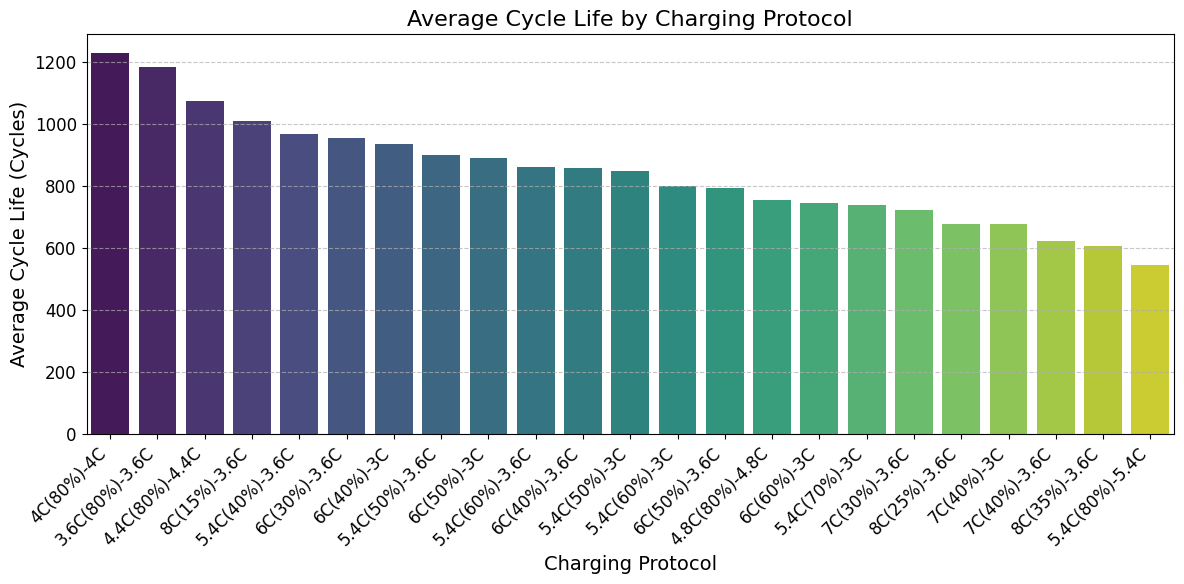


📌 [충전 프로토콜별 평균 수명 수치]
policy_readable
4C(80%)-4C        1226.5
3.6C(80%)-3.6C    1182.0
4.4C(80%)-4.4C    1074.0
8C(15%)-3.6C      1008.5
5.4C(40%)-3.6C     966.5
6C(30%)-3.6C       952.5
6C(40%)-3C         935.5
5.4C(50%)-3.6C     899.5
6C(50%)-3C         888.5
5.4C(60%)-3.6C     859.5
6C(40%)-3.6C       856.0
5.4C(50%)-3C       847.0
5.4C(60%)-3C       799.5
6C(50%)-3.6C       792.5
4.8C(80%)-4.8C     753.0
6C(60%)-3C         744.0
5.4C(70%)-3C       739.5
7C(30%)-3.6C       722.5
8C(25%)-3.6C       676.5
7C(40%)-3C         676.0
7C(40%)-3.6C       621.0
8C(35%)-3.6C       607.5
5.4C(80%)-5.4C     546.5
Name: cycle_life, dtype: float64


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_list = []

for i, cell in enumerate(batch):
    # A. 수명 데이터 (Target)
    cl = cell['cycle_life']
    cycle_life = float(np.atleast_1d(cl)[0])
    
    # B. 충전 프로토콜 (텍스트)
    policy = cell['policy_readable']
    if isinstance(policy, (list, np.ndarray)):
        policy = str(policy[0])
    else:
        policy = str(policy)
        
    # 리스트에 담기
    data_list.append({
        'cell_id': f'Cell_{i+1}',
        'policy_readable': policy,
        'cycle_life': cycle_life
    })

# DataFrame 생성
df = pd.DataFrame(data_list)
display(df.head())

# ==========================================
# 충전 프로토콜별 평균 수명 시각화
# ==========================================
# 같은 프로토콜(policy_readable)끼리 묶어서 수명(cycle_life)의 평균을 내고, 긴 순서대로 정렬합니다.
policy_mean = df.groupby('policy_readable')['cycle_life'].mean().sort_values(ascending=False)

# 막대그래프(Bar plot) 그리기
plt.figure(figsize=(12, 6))
sns.barplot(x=policy_mean.index, y=policy_mean.values, palette='viridis')

plt.title('Average Cycle Life by Charging Protocol', fontsize=16)
plt.xlabel('Charging Protocol', fontsize=14)
plt.ylabel('Average Cycle Life (Cycles)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# 실제 계산된 평균 수명 수치로도 확인하기
print("\n📌 [충전 프로토콜별 평균 수명 수치]")
print(policy_mean)

### 결과 해석

- 충전 속도와 수명의 반비례 관계 확인 : 그래프 좌측에 위치한 1100~1200 사이클 셀들은 상대적으로 낮은 1차 고속 충전 속도를 사용한 반면, 우측의 500~600 사이클 셀들은 높은 고속 충전 속도를 사용함
- 초기에 강한 전류를 넣을수록 배터리 내부의 열화가 가속되어 전체 수명이 크게 떨어짐을 시각적으로 확인함

### (Q2) 사이클 별 Qd 추이 시각화

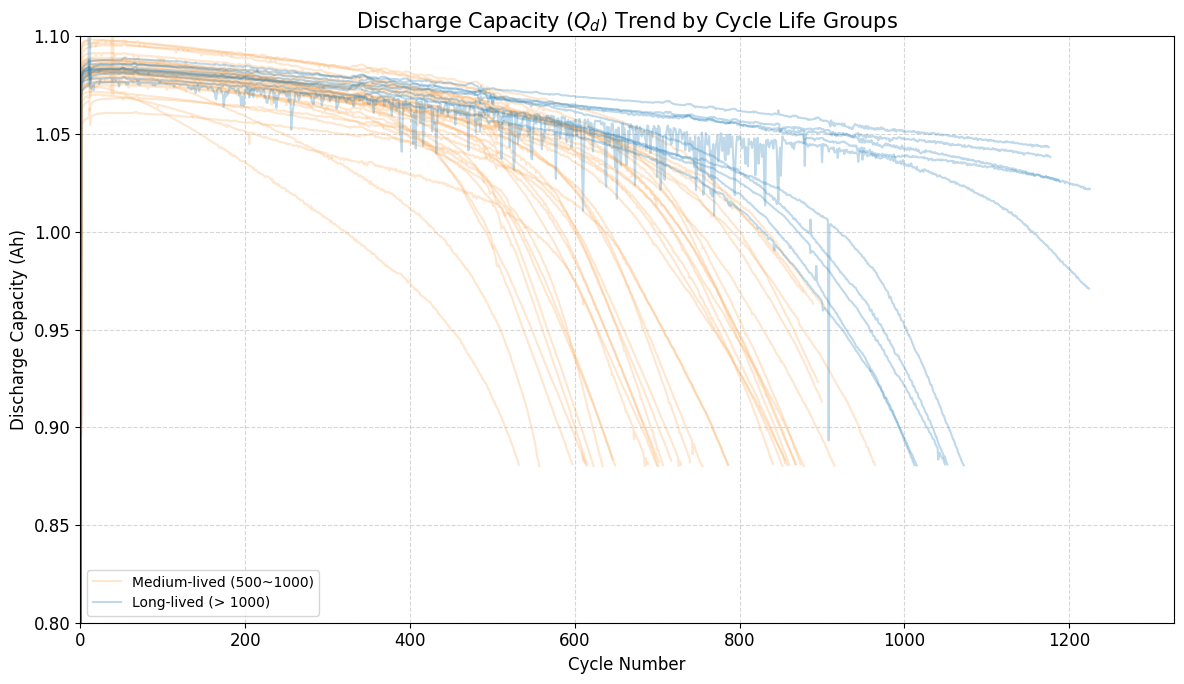

📌 그룹별 배터리 개수 확인
- Short-lived  : 0개
- Medium-lived : 36개
- Long-lived   : 10개


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 수명 구간별 그룹화 (Short, Medium, Long)
# 인덱스를 맞춰주기 위해 df의 수명 정보를 기준으로 각 셀을 분류합니다.
short_life_indices = df[df['cycle_life'] <= 500].index
medium_life_indices = df[(df['cycle_life'] > 500) & (df['cycle_life'] <= 1000)].index
long_life_indices = df[df['cycle_life'] > 1000].index

# 2. 시각화 설정
plt.figure(figsize=(12, 7))

def plot_qd_trend(indices, label, color):
    first_flag = True
    for idx in indices:
        cell = batch[idx]
        # summary에서 방전 용량(Qd) 데이터 추출 및 차원 정리
        qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
        qd_flat = np.array(qd).flatten()
        
        cycles = np.arange(len(qd_flat))
        
        # 각 그룹별로 첫 번째 선에만 범례(Label) 표시
        current_label = label if first_flag else None
        plt.plot(cycles, qd_flat, color=color, alpha=0.3, label=current_label)
        first_flag = False

# 3. 각 구간별 데이터 플로팅
plot_qd_trend(short_life_indices, 'Short-lived (<= 500)', '#d7191c')   # 빨간색계열
plot_qd_trend(medium_life_indices, 'Medium-lived (500~1000)', '#fdae61') # 주황색계열
plot_qd_trend(long_life_indices, 'Long-lived (> 1000)', '#2b83ba')     # 파란색계열

# 4. 그래프 디테일 설정
plt.title('Discharge Capacity ($Q_d$) Trend by Cycle Life Groups', fontsize=15)
plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (Ah)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# 그래프 범위 설정 (수명이 긴 배터리 기준으로 X축 최댓값 설정)
max_cycle = df['cycle_life'].max()
plt.xlim(0, max_cycle + 100)
plt.ylim(0.8, 1.1) # 일반적인 LFP 배터리 용량 범위에 맞춰 조정

plt.tight_layout()
plt.show()

# 5. 각 그룹별 샘플 수 확인
print(f"📌 그룹별 배터리 개수 확인")
print(f"- Short-lived  : {len(short_life_indices)}개")
print(f"- Medium-lived : {len(medium_life_indices)}개")
print(f"- Long-lived   : {len(long_life_indices)}개")

### 1차, 2차 충전 속도 차이별 평균 수명 비교

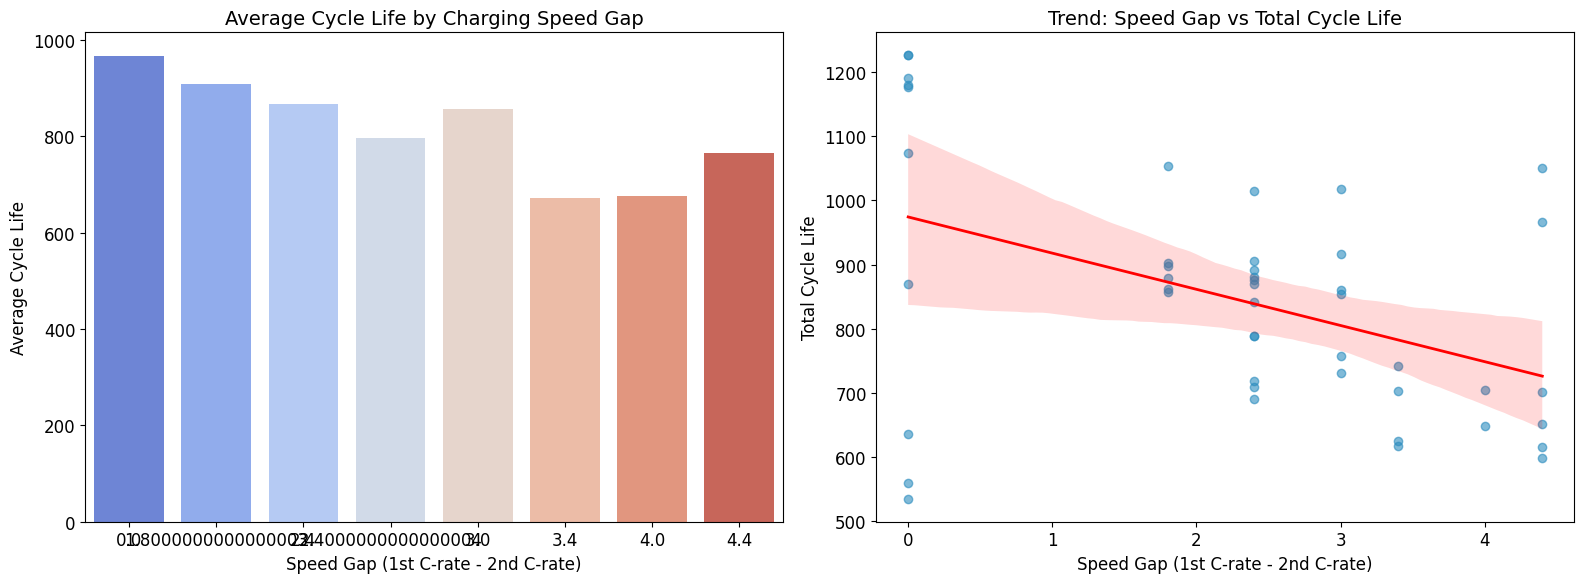


📌 [충전 속도 차이(Gap)별 평균 수명]


,speed_gap,cycle_life
0,0.0,967.200000
1,1.8,908.500000
2,2.4,867.000000
3,2.4,795.333333
4,3.0,856.000000
5,3.4,671.750000
6,4.0,676.000000
7,4.4,764.166667



- 속도 차이(Gap)와 수명의 상관계수: -0.442


In [ ]:
# ==========================================
# 1차, 2차 충전 속도 추출 및 차이(Gap) 계산
# ==========================================
df['first_c_rate'] = df['policy_readable'].str.extract(r'^(\d+(?:[._]\d+)?)C').replace('_', '.', regex=True).astype(float)
df['second_c_rate'] = df['policy_readable'].str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C').replace('_', '.', regex=True).astype(float)

# 속도 차이 파생변수 생성 (1차 속도 - 2차 속도)
# 예: 5.4C - 3.0C = 2.4 (속도를 크게 줄임) / 3.6C - 3.6C = 0.0 (속도 유지)
df['speed_gap'] = df['first_c_rate'] - df['second_c_rate']

# NaN(결측치)이 있는 행 제거 (계산 불가능한 특수 프로토콜 제외)
df_clean = df.dropna(subset=['speed_gap', 'cycle_life'])

# ==========================================
# 속도 차이(Gap)별 평균 수명 계산
# ==========================================
# 속도 차이값을 기준으로 그룹화하여 평균 수명 계산
gap_mean = df_clean.groupby('speed_gap')['cycle_life'].mean().reset_index()

# ==========================================
# 3. 시각화 (산점도 추세선 + 막대그래프)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 막대 그래프: 속도 차이별 평균 수명 (직관적 비교)
sns.barplot(x='speed_gap', y='cycle_life', data=gap_mean, palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Cycle Life by Charging Speed Gap', fontsize=14)
axes[0].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[0].set_ylabel('Average Cycle Life', fontsize=12)

# [그래프 2] 산점도 및 회귀선: 전체 데이터의 추세 확인
sns.regplot(x='speed_gap', y='cycle_life', data=df_clean, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('Trend: Speed Gap vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# 수치로 확인하기
print("\n📌 [충전 속도 차이(Gap)별 평균 수명]")
display(gap_mean.sort_values(by='speed_gap'))

# 상관계수 확인
gap_corr = df_clean['speed_gap'].corr(df_clean['cycle_life'])
print(f"\n- 속도 차이(Gap)와 수명의 상관계수: {gap_corr:.3f}")

### 고속 충전 셀이 정말 수명이 짧은가?

데이터 확인:


,policy_readable,first_c_rate,soc_percent,second_c_rate,cycle_life
0,3.6C(80%)-3.6C,3.6,80.0,3.6,1190.0
1,3.6C(80%)-3.6C,3.6,80.0,3.6,1179.0
2,3.6C(80%)-3.6C,3.6,80.0,3.6,1177.0
3,4C(80%)-4C,4.0,80.0,4.0,1226.0
4,4C(80%)-4C,4.0,80.0,4.0,1227.0


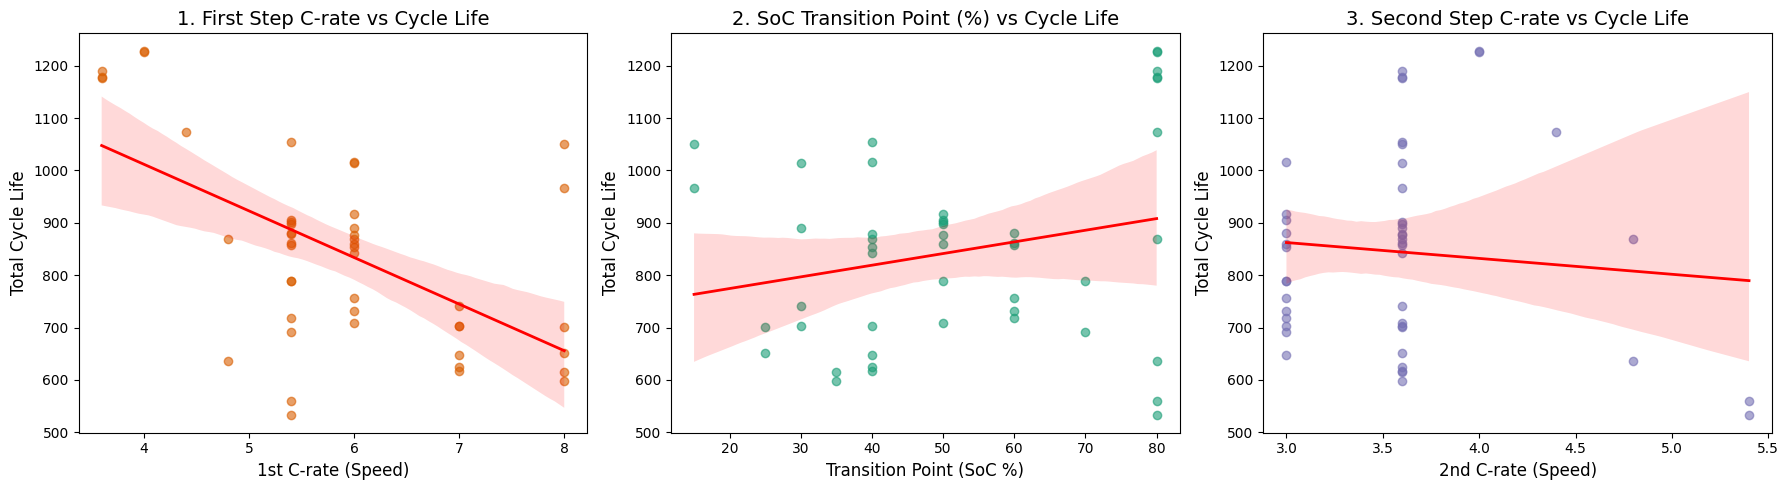


📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]
- 1차 충전 속도의 영향력 : -0.580 (가장 강력한 음의 상관관계)
- 전환 구간(%)의 영향력   : 0.235
- 2차 충전 속도의 영향력 : -0.096


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# policy_readable에서 3가지 변수 분리
# ==========================================
# policy_readable 문자열 (예: '5.4C(40%)-3.0C')에서 각각의 숫자 추출
# 1) 1차 충전 속도
df['first_c_rate'] = (df['policy_readable']
                      .str.extract(r'^(\d+(?:[._]\d+)?)C', expand=False)
                      .str.replace('_', '.')
                      .astype(float))

# 2) 전환 구간(%)
df['soc_percent'] = (df['policy_readable']
                     .str.extract(r'(\d+)(?:PER|%)', expand=False)
                     .astype(float))

# 3) 2차 충전 속도
df['second_c_rate'] = (df['policy_readable']
                       .str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C', expand=False)
                       .str.replace('_', '.')
                       .astype(float))

print("데이터 확인:")
display(df[['policy_readable', 'first_c_rate', 'soc_percent', 'second_c_rate', 'cycle_life']].head())

# ==========================================
# 3가지 변수와 최종 수명(Target)의 관계 시각화
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [그래프 1] 1차 충전 속도 vs 수명
sns.regplot(x='first_c_rate', y='cycle_life', data=df, ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'#d95f02'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First Step C-rate vs Cycle Life', fontsize=14)
axes[0].set_xlabel('1st C-rate (Speed)', fontsize=12)
axes[0].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 2] 1차 충전 유지 구간(%) vs 수명
sns.regplot(x='soc_percent', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#1b9e77'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. SoC Transition Point (%) vs Cycle Life', fontsize=14)
axes[1].set_xlabel('Transition Point (SoC %)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 3] 2차 충전 속도 vs 수명
sns.regplot(x='second_c_rate', y='cycle_life', data=df, ax=axes[2],
            scatter_kws={'alpha':0.6, 'color':'#7570b3'}, line_kws={'color':'red', 'lw':2})
axes[2].set_title('3. Second Step C-rate vs Cycle Life', fontsize=14)
axes[2].set_xlabel('2nd C-rate (Speed)', fontsize=12)
axes[2].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 피어슨 상관계수로 확인
# ==========================================
print("\n📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]")
corr_1st = df['first_c_rate'].corr(df['cycle_life'])
corr_soc = df['soc_percent'].corr(df['cycle_life'])
corr_2nd = df['second_c_rate'].corr(df['cycle_life'])

print(f"- 1차 충전 속도의 영향력 : {corr_1st:.3f} (가장 강력한 음의 상관관계)")
print(f"- 전환 구간(%)의 영향력   : {corr_soc:.3f}")
print(f"- 2차 충전 속도의 영향력 : {corr_2nd:.3f}")

### 결과 해석

- policy_readable 에 변수 3개 (1차 충전 속도, 전환 구간, 2차 충전 속도) 가 섞여 있어 이를 독립적인 칼럼으로 분리한 뒤 각각이 수명과 어떤 상관관계가 있는지 비교함
- [1차 충전 속도] 상관계수가 -0.580으로 강한 음의 상관관계를 나타냄. 배터리가 비어있는 초반에 충전 속도가 빠를수록 전체 수명이 급격하게 짧아짐을 확인함. 3가지 변수 중 배터리 수명에 가장 큰 영향을 주는 변수임.
- [전환 구간] 0.235의 상관계수로 다소 약한 상관관계를 보임. 1차 고속 충전을 배터리 용량의 몇 %까지 유지할 것인가는 전체 수명을 결정짓는 데 강력한 변수로 작용하지 않음.
- [2차 충전 속도] -0.096의 상관관계를 보이며 수명과 거의 무관함을 확인함. 배터리가 이미 일정 수준 이상 충전된 후반부에는 충전 속도가 배터리의 최종 수명에 유의미한 영향을 주지 않음을 알 수 있음.
- [결론] 배터리 수명을 단축시키는 결정적 원인은 '1차 충전 속도'임을 알 수 있음. 추후 배터리 수명 예측 모델링 시 2차 충전 속도나 전환 구간보다는 '1차 충전 속도'를 핵심 feature로 사용할 수 있을 거라 생각함.

### 충전 전류 패턴과 열화 속도 상관 분석

열화 속도(early_degradation_100) 컬럼 추가 완료


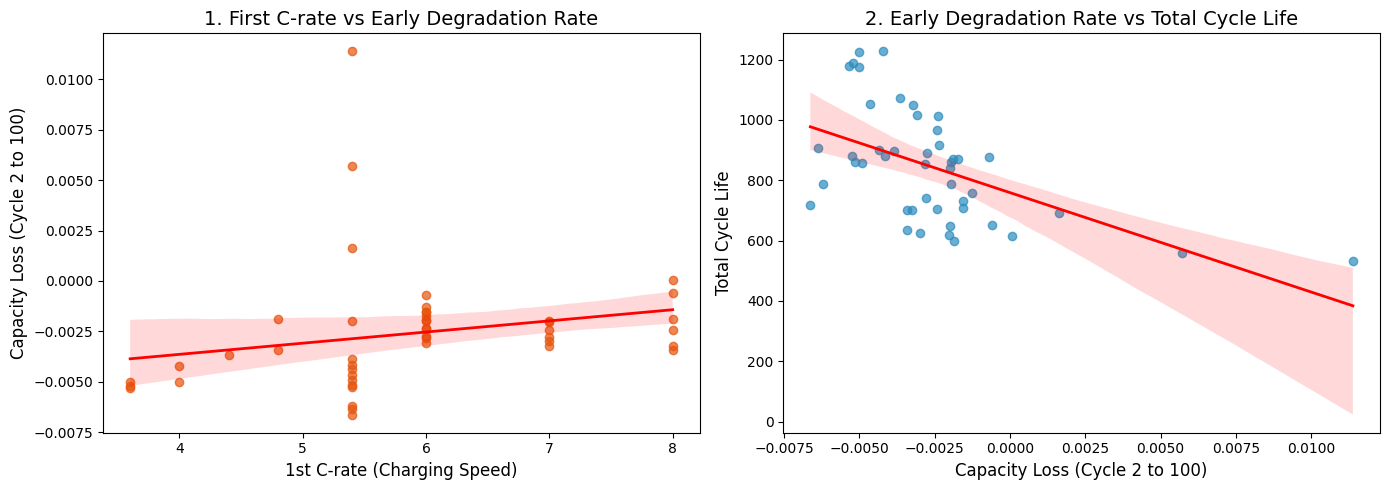


📌 [상관 분석 결과]
- 충전 속도와 초기 열화 속도의 상관계수 : 0.220
- 초기 열화 속도와 최종 수명의 상관계수   : -0.540


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 원본 batch에서 '초기 열화 속도' 계산
# ==========================================
degradation_list = []
for cell in batch:
    # summary에서 방전 용량(Qd) 배열 가져오기
    summary_qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
    
    # 2번째 사이클(인덱스 1)과 100번째 사이클(인덱스 99)의 용량 차이(감소량) 계산
    if len(summary_qd) >= 100:
        early_deg = float(summary_qd[1]) - float(summary_qd[99])
    else:
        early_deg = np.nan
        
    degradation_list.append(early_deg)

# df에 '초기 100사이클 열화량' 컬럼 추가
df['early_degradation_100'] = degradation_list

print("열화 속도(early_degradation_100) 컬럼 추가 완료")

# ==========================================
# 충전 속도 vs 열화 속도 vs 최종 수명 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] 1차 충전 속도 vs 초기 열화 속도
sns.regplot(x='first_c_rate', y='early_degradation_100', data=df, ax=axes[0],
            scatter_kws={'alpha':0.7, 'color':'#e6550d'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First C-rate vs Early Degradation Rate', fontsize=14)
axes[0].set_xlabel('1st C-rate (Charging Speed)', fontsize=12)
axes[0].set_ylabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)

# [그래프 2] 초기 열화 속도 vs 최종 수명
sns.regplot(x='early_degradation_100', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.7, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. Early Degradation Rate vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 상관계수 확인
# ==========================================
print("\n📌 [상관 분석 결과]")
corr_c_deg = df['first_c_rate'].corr(df['early_degradation_100'])
corr_deg_life = df['early_degradation_100'].corr(df['cycle_life'])

print(f"- 충전 속도와 초기 열화 속도의 상관계수 : {corr_c_deg:.3f}")
print(f"- 초기 열화 속도와 최종 수명의 상관계수   : {corr_deg_life:.3f}")

### 결과 해석

- X 변수 : 충전 전류 패턴 - 1차 충전 속도 사용
- Y 변수 : 열화 속도 - 초기 100사이클 용량 감소량 (2번째 사이클의 방전 용량 - 100번째 사이클의 방전 용량)
- 초기 100 사이클 데이터만으로 배터리의 잔여 수명을 예측하는 머신러닝 모델을 구축할 수 있도록 100 사이클을 사용함
- [1차 충전 속도 vs 초기 열화 속도] 1차 충전 속도와 초기 열화 속도가 0.220의 양의 상관관계를 가짐을 확인함. 초반에 강한 전류를 주입할수록 100사이클 만에 배터리 용량에 더 많이 감소함을 알 수 있음.
- [초기 열화 속도 vs 최종 수명] 초기 열화 속도와 최종 수명은 -0.540의 음의 상관관계를 가짐. 100사이클 동안 용량이 많이 깎인 배터리일수록 최종 수명도 급격하게 짧아지는 우하향 추세를 확인함.


### 충전 전류 패턴(1, 2차 충전 속도 차이)과 열화 속도 상관 분석

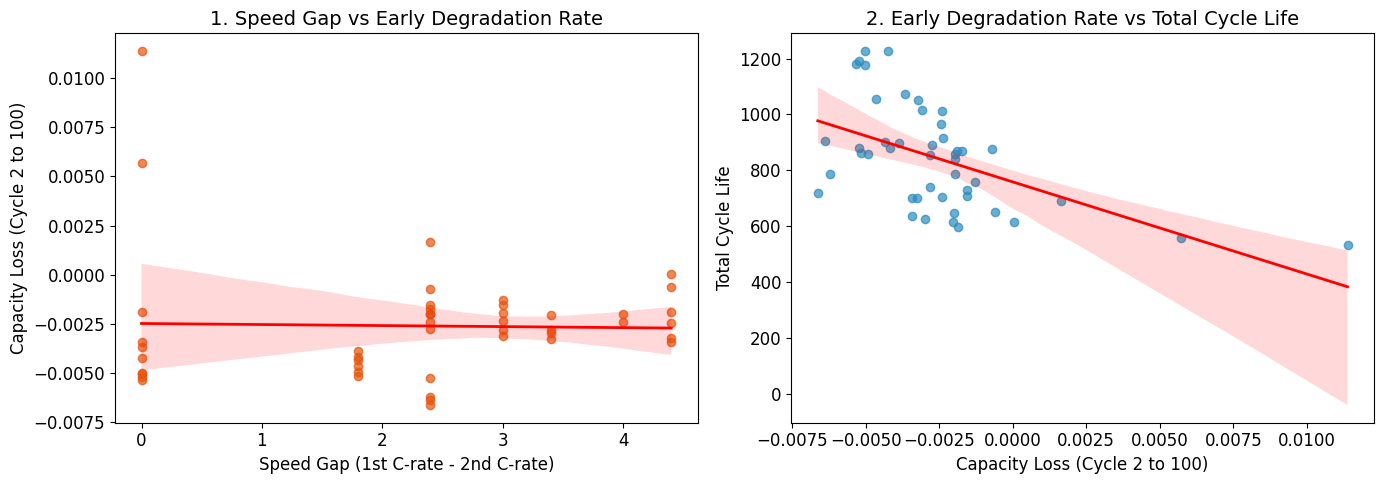


📌 [상관 분석 결과 (속도 차이 기준)]
- 속도 차이(Gap)와 초기 열화 속도의 상관계수 : -0.025
- 초기 열화 속도와 최종 수명의 상관계수   : -0.540


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 속도 차이(speed_gap) 파생 변수 생성 
# ==========================================
if 'speed_gap' not in df.columns:
    df['speed_gap'] = df['first_c_rate'] - df['second_c_rate']

# ==========================================
# 원본 batch에서 '초기 열화 속도' 계산
# ==========================================
degradation_list = []
for cell in batch:
    # summary에서 방전 용량(Qd) 배열 가져오기 (에러 방지를 위해 flatten 적용)
    summary_qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
    qd_flat = np.array(summary_qd).flatten()
    
    # 2번째 사이클(인덱스 1)과 100번째 사이클(인덱스 99)의 용량 차이(감소량) 계산
    if len(qd_flat) >= 100:
        early_deg = float(qd_flat[1]) - float(qd_flat[99])
    else:
        early_deg = np.nan
        
    degradation_list.append(early_deg)

# df에 '초기 100사이클 열화량' 컬럼 추가
df['early_degradation_100'] = degradation_list

# ==========================================
# 속도 차이 vs 열화 속도 vs 최종 수명 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] 1, 2차 충전 속도 차이(Gap) vs 초기 열화 속도 ⭐️ (여기가 바뀌었습니다)
sns.regplot(x='speed_gap', y='early_degradation_100', data=df, ax=axes[0],
            scatter_kws={'alpha':0.7, 'color':'#e6550d'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. Speed Gap vs Early Degradation Rate', fontsize=14)
axes[0].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[0].set_ylabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)

# [그래프 2] 초기 열화 속도 vs 최종 수명 (기존과 동일)
sns.regplot(x='early_degradation_100', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.7, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. Early Degradation Rate vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 상관계수 확인
# ==========================================
print("\n📌 [상관 분석 결과 (속도 차이 기준)]")

# 결측치(NaN)를 제외하고 상관계수 계산
df_clean = df.dropna(subset=['speed_gap', 'early_degradation_100', 'cycle_life'])

corr_gap_deg = df_clean['speed_gap'].corr(df_clean['early_degradation_100'])
corr_deg_life = df_clean['early_degradation_100'].corr(df_clean['cycle_life'])

print(f"- 속도 차이(Gap)와 초기 열화 속도의 상관계수 : {corr_gap_deg:.3f}")
print(f"- 초기 열화 속도와 최종 수명의 상관계수   : {corr_deg_life:.3f}")

### Correlation Matrix

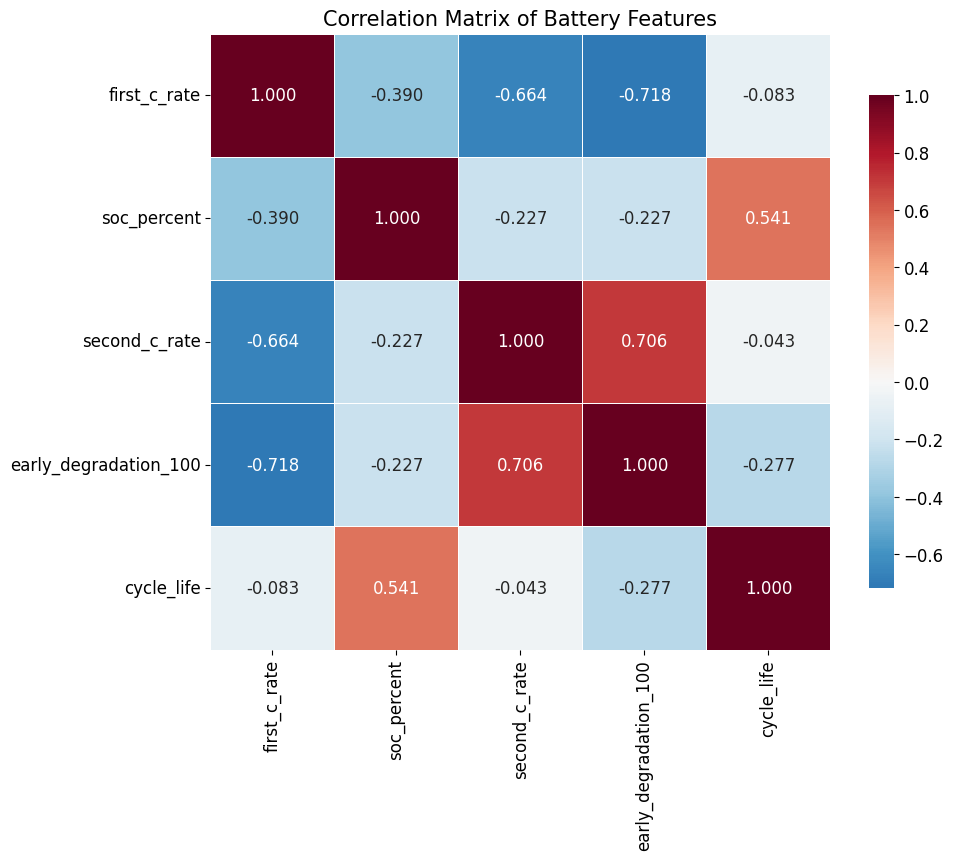


📌 [수명(cycle_life)과의 상관계수 순위]
cycle_life               1.000000
soc_percent              0.541360
second_c_rate           -0.042746
first_c_rate            -0.082899
early_degradation_100   -0.277331
Name: cycle_life, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관분석에 사용할 핵심 변수들만 선택
features = ['first_c_rate', 'soc_percent', 'second_c_rate', 'early_degradation_100', 'cycle_life']

# 2. 상관계수 계산 (데이터프레임 내 변수 간의 피어슨 상관계수)
corr = df[features].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,           # 숫자 표시
            fmt=".3f",            # 소수점 셋째자리까지
            cmap='RdBu_r',        # 빨간색(양의 상관), 파란색(음의 상관)
            center=0,             # 0을 기준으로 색상 분리
            linewidths=0.5,       # 칸 사이 구분선
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Battery Features', fontsize=15)
plt.show()

# 4. 수명(cycle_life)과의 상관계수만 따로 내림차순 정렬해서 보기
print(f"\n📌 [수명(cycle_life)과의 상관계수 순위]")
print(corr['cycle_life'].sort_values(ascending=False))

## 충전 프로토콜별 평균 수명 비교 (Batch 2)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mat73
import os

In [25]:
data_dir = 'data'
file_name = '2018-02-20_batchdata_updated_struct_errorcorrect.mat'
file_path = os.path.join(data_dir, file_name)

mat = mat73.loadmat(file_path)
batch_raw = mat['batch']

# mat73 -> list of dict
if isinstance(batch_raw, dict):
    keys = list(batch_raw.keys())
    n_cells = len(batch_raw[keys[0]])
    batch = [{k: batch_raw[k][i] for k in keys} for i in range(n_cells)]

print("원본 데이터(batch) 로드 완료")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

원본 데이터(batch) 로드 완료


,cell_id,policy_readable,cycle_life
0,Cell_1,5.2C(58%)-4C,477.0
1,Cell_2,5.6C(26%)-4.5C,491.0
2,Cell_3,5.2C(50%)-4.25C,424.0
3,Cell_4,4.65C(44%)-5C,499.0
4,Cell_5,4.65C(69%)-6C,444.0


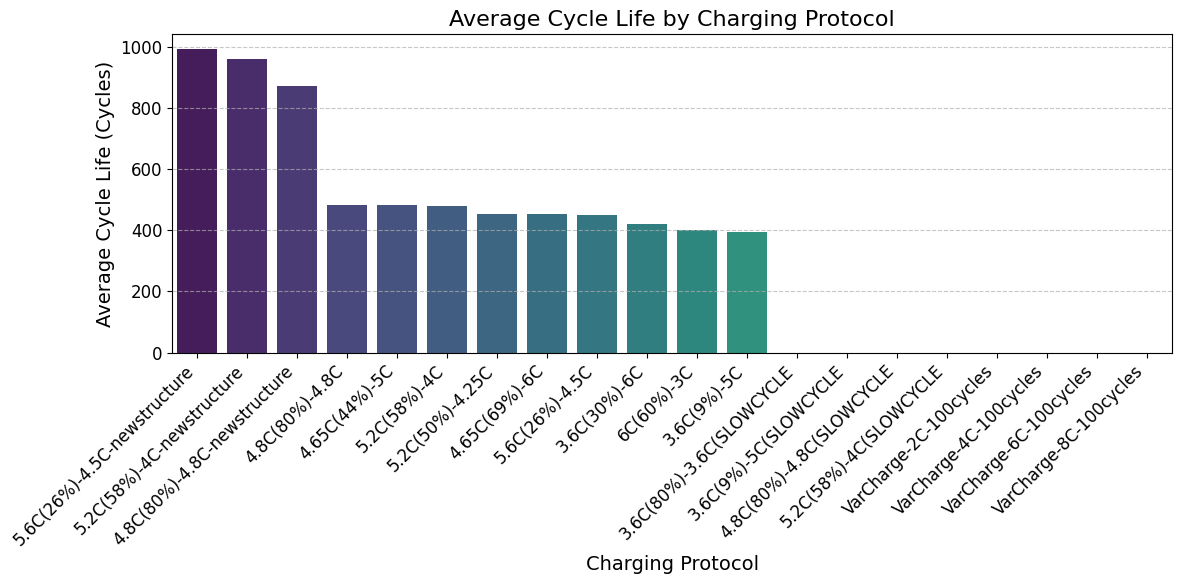


📌 [충전 프로토콜별 평균 수명 수치]
policy_readable
5.6C(26%)-4.5C-newstructure    991.333333
5.2C(58%)-4C-newstructure      961.666667
4.8C(80%)-4.8C-newstructure    871.666667
4.8C(80%)-4.8C                 483.600000
4.65C(44%)-5C                  482.500000
5.2C(58%)-4C                   477.750000
5.2C(50%)-4.25C                454.000000
4.65C(69%)-6C                  452.000000
5.6C(26%)-4.5C                 448.500000
3.6C(30%)-6C                   421.000000
6C(60%)-3C                     400.000000
3.6C(9%)-5C                    394.500000
3.6C(80%)-3.6C(SLOWCYCLE              NaN
3.6C(9%)-5C(SLOWCYCLE                 NaN
4.8C(80%)-4.8C(SLOWCYCLE              NaN
5.2C(58%)-4C(SLOWCYCLE                NaN
VarCharge-2C-100cycles                NaN
VarCharge-4C-100cycles                NaN
VarCharge-6C-100cycles                NaN
VarCharge-8C-100cycles                NaN
Name: cycle_life, dtype: float64


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_list = []

for i, cell in enumerate(batch):
    # A. 수명 데이터 (Target)
    cl = cell['cycle_life']
    cycle_life = float(np.atleast_1d(cl)[0])
    
    # B. 충전 프로토콜 (텍스트)
    policy = cell['policy_readable']
    if isinstance(policy, (list, np.ndarray)):
        policy = str(policy[0])
    else:
        policy = str(policy)
        
    # 리스트에 담기
    data_list.append({
        'cell_id': f'Cell_{i+1}',
        'policy_readable': policy,
        'cycle_life': cycle_life
    })

# DataFrame 생성
df = pd.DataFrame(data_list)
display(df.head())

# ==========================================
# 충전 프로토콜별 평균 수명 시각화
# ==========================================
# 같은 프로토콜(policy_readable)끼리 묶어서 수명(cycle_life)의 평균을 내고, 긴 순서대로 정렬합니다.
policy_mean = df.groupby('policy_readable')['cycle_life'].mean().sort_values(ascending=False)

# 막대그래프(Bar plot) 그리기
plt.figure(figsize=(12, 6))
sns.barplot(x=policy_mean.index, y=policy_mean.values, palette='viridis')

plt.title('Average Cycle Life by Charging Protocol', fontsize=16)
plt.xlabel('Charging Protocol', fontsize=14)
plt.ylabel('Average Cycle Life (Cycles)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# 실제 계산된 평균 수명 수치로도 확인하기
print("\n📌 [충전 프로토콜별 평균 수명 수치]")
print(policy_mean)

### (Q2) 사이클 별 Qd 추이 시각화

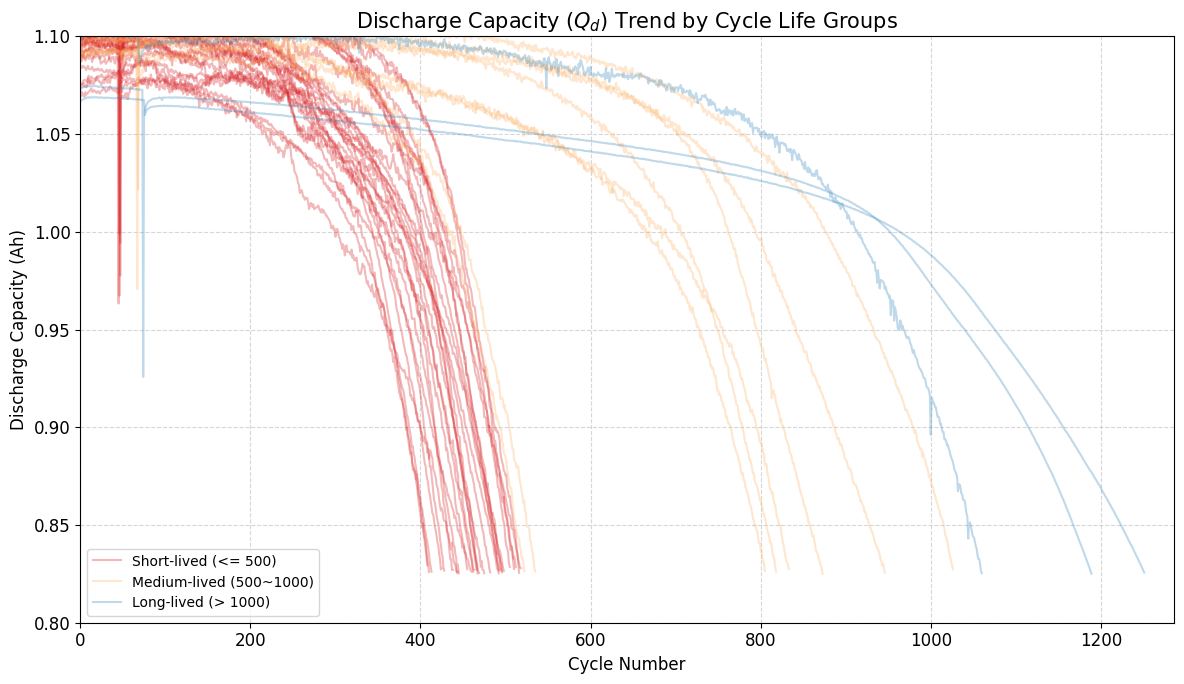

📌 그룹별 배터리 개수 확인
- Short-lived  : 28개
- Medium-lived : 8개
- Long-lived   : 3개


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 수명 구간별 그룹화 (Short, Medium, Long)
# 인덱스를 맞춰주기 위해 df의 수명 정보를 기준으로 각 셀을 분류합니다.
short_life_indices = df[df['cycle_life'] <= 500].index
medium_life_indices = df[(df['cycle_life'] > 500) & (df['cycle_life'] <= 1000)].index
long_life_indices = df[df['cycle_life'] > 1000].index

# 2. 시각화 설정
plt.figure(figsize=(12, 7))

def plot_qd_trend(indices, label, color):
    first_flag = True
    for idx in indices:
        cell = batch[idx]
        # summary에서 방전 용량(Qd) 데이터 추출 및 차원 정리
        qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
        qd_flat = np.array(qd).flatten()
        
        cycles = np.arange(len(qd_flat))
        
        # 각 그룹별로 첫 번째 선에만 범례(Label) 표시
        current_label = label if first_flag else None
        plt.plot(cycles, qd_flat, color=color, alpha=0.3, label=current_label)
        first_flag = False

# 3. 각 구간별 데이터 플로팅
plot_qd_trend(short_life_indices, 'Short-lived (<= 500)', '#d7191c')   # 빨간색계열
plot_qd_trend(medium_life_indices, 'Medium-lived (500~1000)', '#fdae61') # 주황색계열
plot_qd_trend(long_life_indices, 'Long-lived (> 1000)', '#2b83ba')     # 파란색계열

# 4. 그래프 디테일 설정
plt.title('Discharge Capacity ($Q_d$) Trend by Cycle Life Groups', fontsize=15)
plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (Ah)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# 그래프 범위 설정 (수명이 긴 배터리 기준으로 X축 최댓값 설정)
max_cycle = df['cycle_life'].max()
plt.xlim(0, max_cycle + 100)
plt.ylim(0.8, 1.1) # 일반적인 LFP 배터리 용량 범위에 맞춰 조정

plt.tight_layout()
plt.show()

# 5. 각 그룹별 샘플 수 확인
print(f"📌 그룹별 배터리 개수 확인")
print(f"- Short-lived  : {len(short_life_indices)}개")
print(f"- Medium-lived : {len(medium_life_indices)}개")
print(f"- Long-lived   : {len(long_life_indices)}개")

### 1차, 2차 충전 속도 차이별 평균 수명 비교

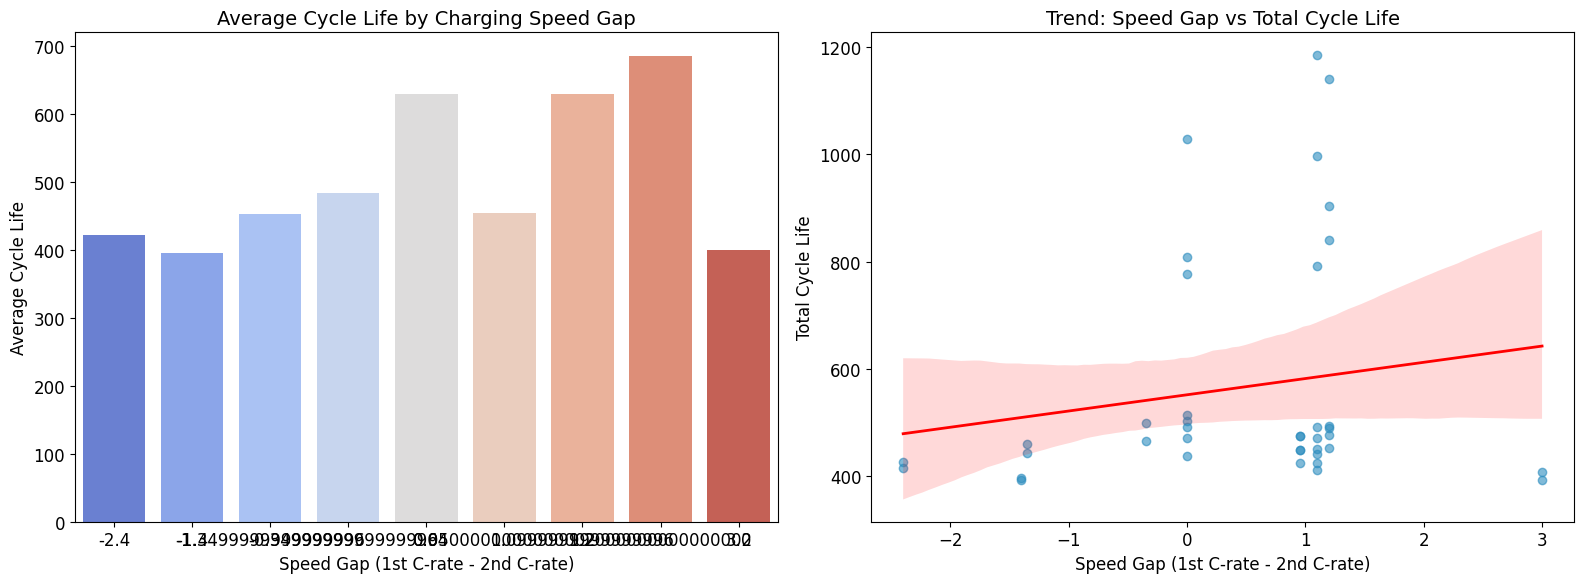


📌 [충전 속도 차이(Gap)별 평균 수명]


,speed_gap,cycle_life
0,-2.40,421.000000
1,-1.40,394.500000
2,-1.35,452.000000
3,-0.35,482.500000
4,0.00,629.125000
5,0.95,454.000000
6,1.10,629.444444
7,1.20,685.142857
8,3.00,400.000000



- 속도 차이(Gap)와 수명의 상관계수: 0.163


In [18]:
# ==========================================
# 1차, 2차 충전 속도 추출 및 차이(Gap) 계산
# ==========================================
df['first_c_rate'] = df['policy_readable'].str.extract(r'^(\d+(?:[._]\d+)?)C').replace('_', '.', regex=True).astype(float)
df['second_c_rate'] = df['policy_readable'].str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C').replace('_', '.', regex=True).astype(float)

# 속도 차이 파생변수 생성 (1차 속도 - 2차 속도)
# 예: 5.4C - 3.0C = 2.4 (속도를 크게 줄임) / 3.6C - 3.6C = 0.0 (속도 유지)
df['speed_gap'] = df['first_c_rate'] - df['second_c_rate']

# NaN(결측치)이 있는 행 제거 (계산 불가능한 특수 프로토콜 제외)
df_clean = df.dropna(subset=['speed_gap', 'cycle_life'])

# ==========================================
# 속도 차이(Gap)별 평균 수명 계산
# ==========================================
# 속도 차이값을 기준으로 그룹화하여 평균 수명 계산
gap_mean = df_clean.groupby('speed_gap')['cycle_life'].mean().reset_index()

# ==========================================
# 3. 시각화 (산점도 추세선 + 막대그래프)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [그래프 1] 막대 그래프: 속도 차이별 평균 수명 (직관적 비교)
sns.barplot(x='speed_gap', y='cycle_life', data=gap_mean, palette='coolwarm', ax=axes[0])
axes[0].set_title('Average Cycle Life by Charging Speed Gap', fontsize=14)
axes[0].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[0].set_ylabel('Average Cycle Life', fontsize=12)

# [그래프 2] 산점도 및 회귀선: 전체 데이터의 추세 확인
sns.regplot(x='speed_gap', y='cycle_life', data=df_clean, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('Trend: Speed Gap vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# 수치로 확인하기
print("\n📌 [충전 속도 차이(Gap)별 평균 수명]")
display(gap_mean.sort_values(by='speed_gap'))

# 상관계수 확인
gap_corr = df_clean['speed_gap'].corr(df_clean['cycle_life'])
print(f"\n- 속도 차이(Gap)와 수명의 상관계수: {gap_corr:.3f}")

### 고속 충전 셀이 정말 수명이 짧은가? (Batch 2)

데이터 확인:


,policy_readable,first_c_rate,soc_percent,second_c_rate,cycle_life
0,5.2C(58%)-4C,5.20,58.0,4.00,477.0
1,5.6C(26%)-4.5C,5.60,26.0,4.50,491.0
2,5.2C(50%)-4.25C,5.20,50.0,4.25,424.0
3,4.65C(44%)-5C,4.65,44.0,5.00,499.0
4,4.65C(69%)-6C,4.65,69.0,6.00,444.0


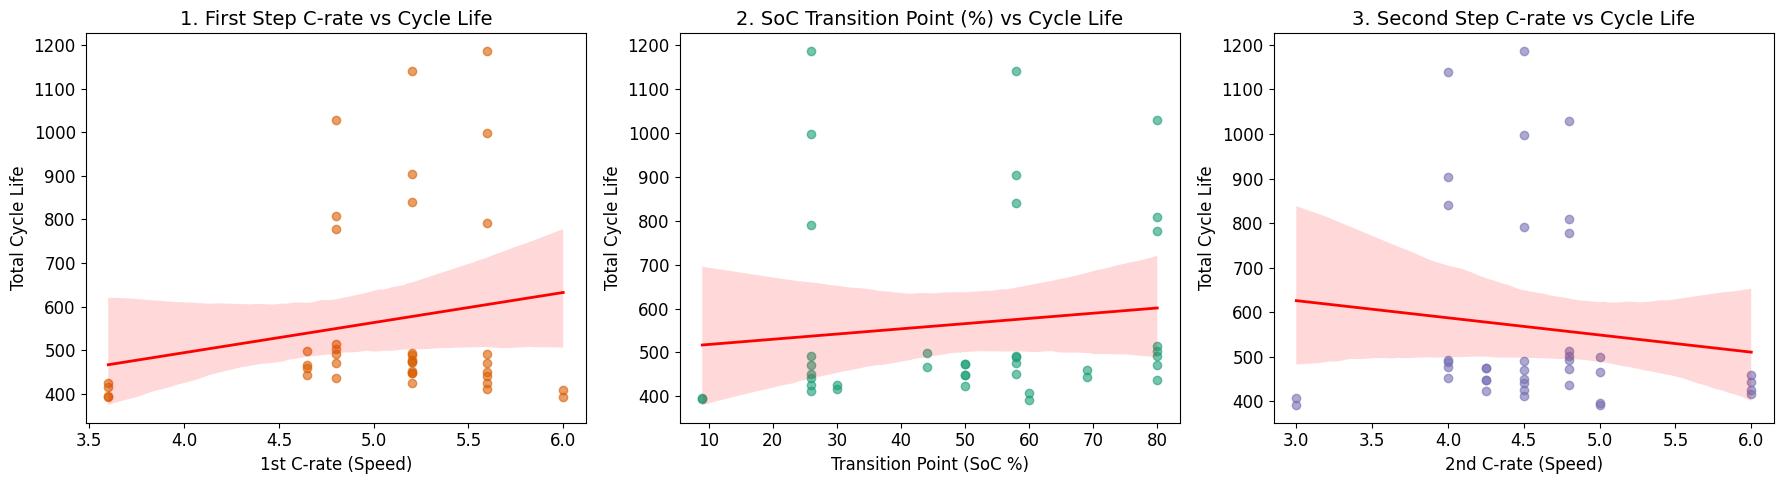


📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]
- 1차 충전 속도의 영향력 : 0.191 (가장 강력한 음의 상관관계)
- 전환 구간(%)의 영향력   : 0.116
- 2차 충전 속도의 영향력 : -0.116


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# policy_readable에서 3가지 변수 분리
# ==========================================
# policy_readable 문자열 (예: '5.4C(40%)-3.0C')에서 각각의 숫자 추출
# 1) 1차 충전 속도
df['first_c_rate'] = (df['policy_readable']
                      .str.extract(r'^(\d+(?:[._]\d+)?)C', expand=False)
                      .str.replace('_', '.')
                      .astype(float))

# 2) 전환 구간(%)
df['soc_percent'] = (df['policy_readable']
                     .str.extract(r'(\d+)(?:PER|%)', expand=False)
                     .astype(float))

# 3) 2차 충전 속도
df['second_c_rate'] = (df['policy_readable']
                       .str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C', expand=False)
                       .str.replace('_', '.')
                       .astype(float))

print("데이터 확인:")
display(df[['policy_readable', 'first_c_rate', 'soc_percent', 'second_c_rate', 'cycle_life']].head())

# ==========================================
# 3가지 변수와 최종 수명(Target)의 관계 시각화
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [그래프 1] 1차 충전 속도 vs 수명
sns.regplot(x='first_c_rate', y='cycle_life', data=df, ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'#d95f02'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First Step C-rate vs Cycle Life', fontsize=14)
axes[0].set_xlabel('1st C-rate (Speed)', fontsize=12)
axes[0].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 2] 1차 충전 유지 구간(%) vs 수명
sns.regplot(x='soc_percent', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#1b9e77'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. SoC Transition Point (%) vs Cycle Life', fontsize=14)
axes[1].set_xlabel('Transition Point (SoC %)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 3] 2차 충전 속도 vs 수명
sns.regplot(x='second_c_rate', y='cycle_life', data=df, ax=axes[2],
            scatter_kws={'alpha':0.6, 'color':'#7570b3'}, line_kws={'color':'red', 'lw':2})
axes[2].set_title('3. Second Step C-rate vs Cycle Life', fontsize=14)
axes[2].set_xlabel('2nd C-rate (Speed)', fontsize=12)
axes[2].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 피어슨 상관계수로 확인
# ==========================================
print("\n📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]")
corr_1st = df['first_c_rate'].corr(df['cycle_life'])
corr_soc = df['soc_percent'].corr(df['cycle_life'])
corr_2nd = df['second_c_rate'].corr(df['cycle_life'])

print(f"- 1차 충전 속도의 영향력 : {corr_1st:.3f} (가장 강력한 음의 상관관계)")
print(f"- 전환 구간(%)의 영향력   : {corr_soc:.3f}")
print(f"- 2차 충전 속도의 영향력 : {corr_2nd:.3f}")

### 충전 전류 패턴과 열화 속도 상관 분석 (Batch 2)

열화 속도(early_degradation_100) 컬럼 추가 완료


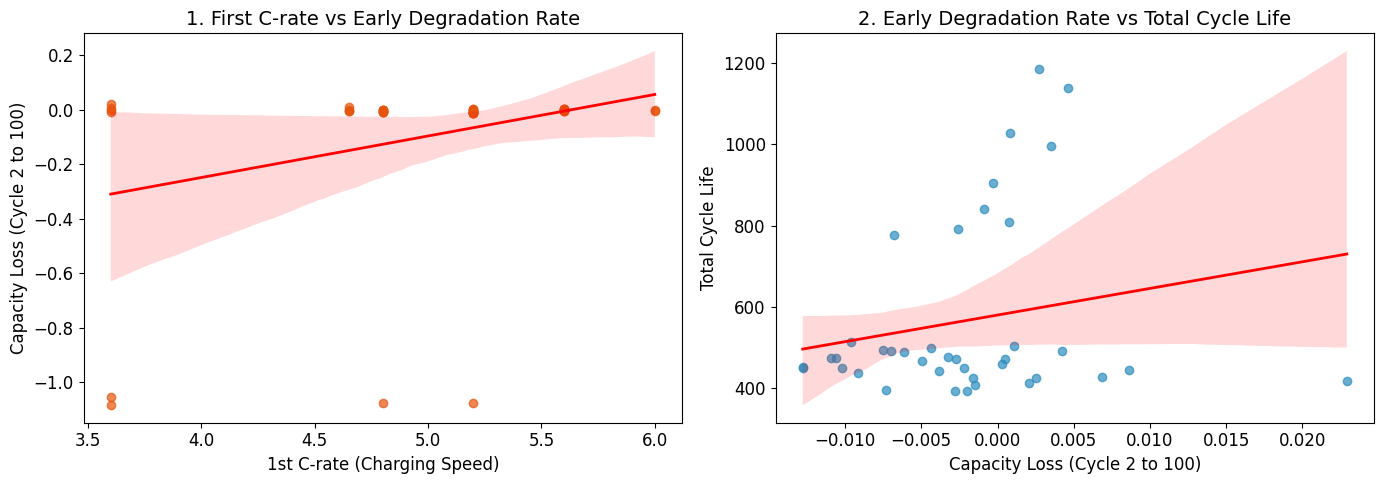


📌 [상관 분석 결과]
- 충전 속도와 초기 열화 속도의 상관계수 : 0.320
- 초기 열화 속도와 최종 수명의 상관계수   : 0.199


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 원본 batch에서 '초기 열화 속도' 계산
# ==========================================
degradation_list = []
for cell in batch:
    # summary에서 방전 용량(Qd) 배열 가져오기
    summary_qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
    
    # 2번째 사이클(인덱스 1)과 100번째 사이클(인덱스 99)의 용량 차이(감소량) 계산
    if len(summary_qd) >= 100:
        early_deg = float(summary_qd[1]) - float(summary_qd[99])
    else:
        early_deg = np.nan
        
    degradation_list.append(early_deg)

# df에 '초기 100사이클 열화량' 컬럼 추가
df['early_degradation_100'] = degradation_list

print("열화 속도(early_degradation_100) 컬럼 추가 완료")

# ==========================================
# 충전 속도 vs 열화 속도 vs 최종 수명 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] 1차 충전 속도 vs 초기 열화 속도
sns.regplot(x='first_c_rate', y='early_degradation_100', data=df, ax=axes[0],
            scatter_kws={'alpha':0.7, 'color':'#e6550d'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First C-rate vs Early Degradation Rate', fontsize=14)
axes[0].set_xlabel('1st C-rate (Charging Speed)', fontsize=12)
axes[0].set_ylabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)

# [그래프 2] 초기 열화 속도 vs 최종 수명
sns.regplot(x='early_degradation_100', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.7, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. Early Degradation Rate vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 상관계수 확인
# ==========================================
print("\n📌 [상관 분석 결과]")
corr_c_deg = df['first_c_rate'].corr(df['early_degradation_100'])
corr_deg_life = df['early_degradation_100'].corr(df['cycle_life'])

print(f"- 충전 속도와 초기 열화 속도의 상관계수 : {corr_c_deg:.3f}")
print(f"- 초기 열화 속도와 최종 수명의 상관계수   : {corr_deg_life:.3f}")

### 충전 전류 패턴(1, 2차 충전 속도 차이)과 열화 속도 상관 분석

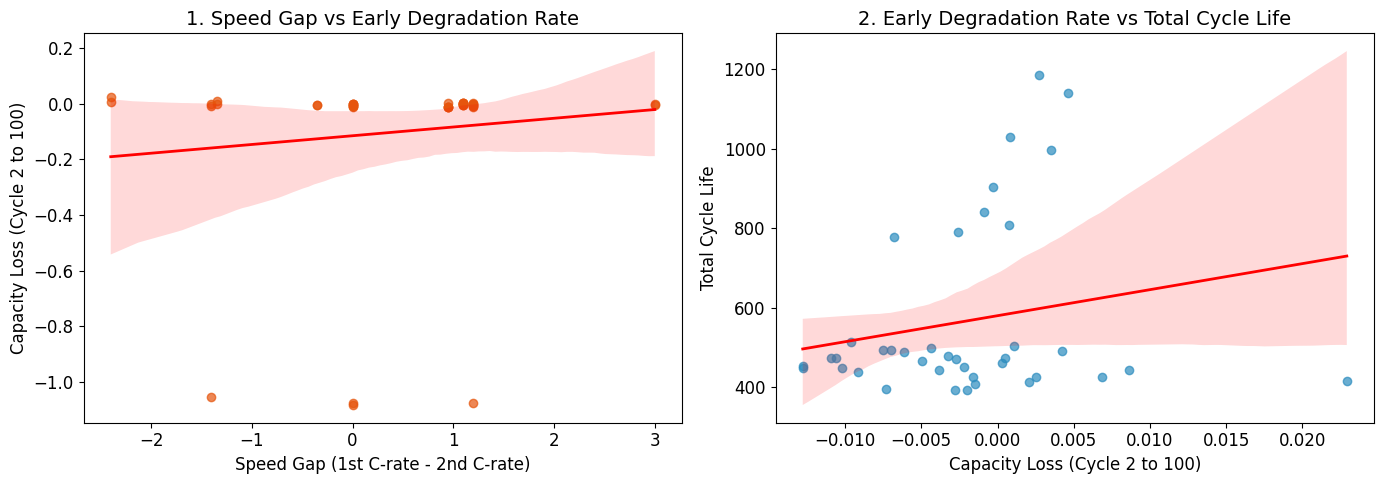


📌 [상관 분석 결과 (속도 차이 기준)]
- 속도 차이(Gap)와 초기 열화 속도의 상관계수 : -0.370
- 초기 열화 속도와 최종 수명의 상관계수   : 0.199


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 속도 차이(speed_gap) 파생 변수 생성 
# ==========================================
if 'speed_gap' not in df.columns:
    df['speed_gap'] = df['first_c_rate'] - df['second_c_rate']

# ==========================================
# 원본 batch에서 '초기 열화 속도' 계산
# ==========================================
degradation_list = []
for cell in batch:
    # summary에서 방전 용량(Qd) 배열 가져오기 (에러 방지를 위해 flatten 적용)
    summary_qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
    qd_flat = np.array(summary_qd).flatten()
    
    # 2번째 사이클(인덱스 1)과 100번째 사이클(인덱스 99)의 용량 차이(감소량) 계산
    if len(qd_flat) >= 100:
        early_deg = float(qd_flat[1]) - float(qd_flat[99])
    else:
        early_deg = np.nan
        
    degradation_list.append(early_deg)

# df에 '초기 100사이클 열화량' 컬럼 추가
df['early_degradation_100'] = degradation_list

# ==========================================
# 속도 차이 vs 열화 속도 vs 최종 수명 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] 1, 2차 충전 속도 차이(Gap) vs 초기 열화 속도 ⭐️ (여기가 바뀌었습니다)
sns.regplot(x='speed_gap', y='early_degradation_100', data=df, ax=axes[0],
            scatter_kws={'alpha':0.7, 'color':'#e6550d'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. Speed Gap vs Early Degradation Rate', fontsize=14)
axes[0].set_xlabel('Speed Gap (1st C-rate - 2nd C-rate)', fontsize=12)
axes[0].set_ylabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)

# [그래프 2] 초기 열화 속도 vs 최종 수명 (기존과 동일)
sns.regplot(x='early_degradation_100', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.7, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. Early Degradation Rate vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 상관계수 확인
# ==========================================
print("\n📌 [상관 분석 결과 (속도 차이 기준)]")

# 결측치(NaN)를 제외하고 상관계수 계산
df_clean = df.dropna(subset=['speed_gap', 'early_degradation_100', 'cycle_life'])

corr_gap_deg = df_clean['speed_gap'].corr(df_clean['early_degradation_100'])
corr_deg_life = df_clean['early_degradation_100'].corr(df_clean['cycle_life'])

print(f"- 속도 차이(Gap)와 초기 열화 속도의 상관계수 : {corr_gap_deg:.3f}")
print(f"- 초기 열화 속도와 최종 수명의 상관계수   : {corr_deg_life:.3f}")

### Correlation Matrix

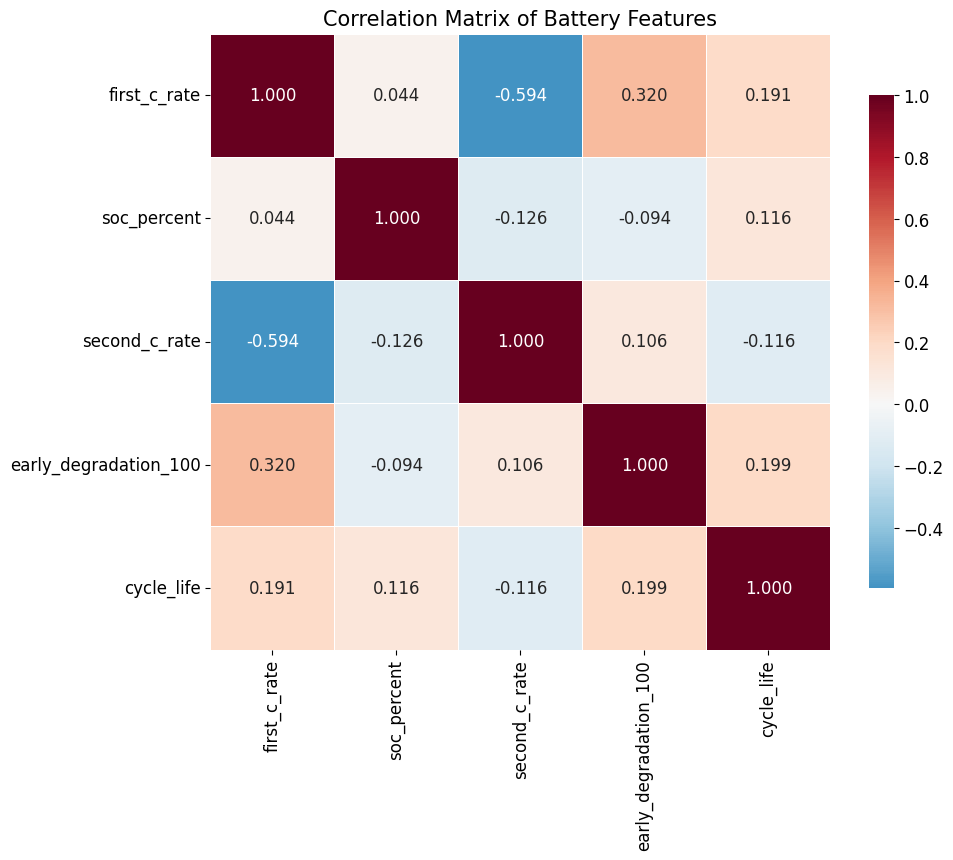


📌 [수명(cycle_life)과의 상관계수 순위]
cycle_life               1.000000
early_degradation_100    0.199276
first_c_rate             0.190747
soc_percent              0.116120
second_c_rate           -0.116305
Name: cycle_life, dtype: float64


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관분석에 사용할 핵심 변수들만 선택
features = ['first_c_rate', 'soc_percent', 'second_c_rate', 'early_degradation_100', 'cycle_life']

# 2. 상관계수 계산 (데이터프레임 내 변수 간의 피어슨 상관계수)
corr = df[features].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,           # 숫자 표시
            fmt=".3f",            # 소수점 셋째자리까지
            cmap='RdBu_r',        # 빨간색(양의 상관), 파란색(음의 상관)
            center=0,             # 0을 기준으로 색상 분리
            linewidths=0.5,       # 칸 사이 구분선
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Battery Features', fontsize=15)
plt.show()

# 4. 수명(cycle_life)과의 상관계수만 따로 내림차순 정렬해서 보기
print(f"\n📌 [수명(cycle_life)과의 상관계수 순위]")
print(corr['cycle_life'].sort_values(ascending=False))

## 충전 프로토콜별 평균 수명 비교 (Batch 3)

In [28]:
data_dir = 'data'
file_name = '2018-04-12_batchdata_updated_struct_errorcorrect.mat'
file_path = os.path.join(data_dir, file_name)

mat = mat73.loadmat(file_path)
batch_raw = mat['batch']

# mat73 -> list of dict
if isinstance(batch_raw, dict):
    keys = list(batch_raw.keys())
    n_cells = len(batch_raw[keys[0]])
    batch = [{k: batch_raw[k][i] for k in keys} for i in range(n_cells)]

print("원본 데이터(batch) 로드 완료")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

원본 데이터(batch) 로드 완료


,cell_id,policy_readable,cycle_life
0,Cell_1,5C(67%)-4C-newstructure,1009.0
1,Cell_2,5.3C(54%)-4C-newstructure,1063.0
2,Cell_3,5.6C(19%)-4.6C-newstructure,1267.0
3,Cell_4,5.6C(36%)-4.3C-newstructure,1115.0
4,Cell_5,5.6C(19%)-4.6C-newstructure,1048.0


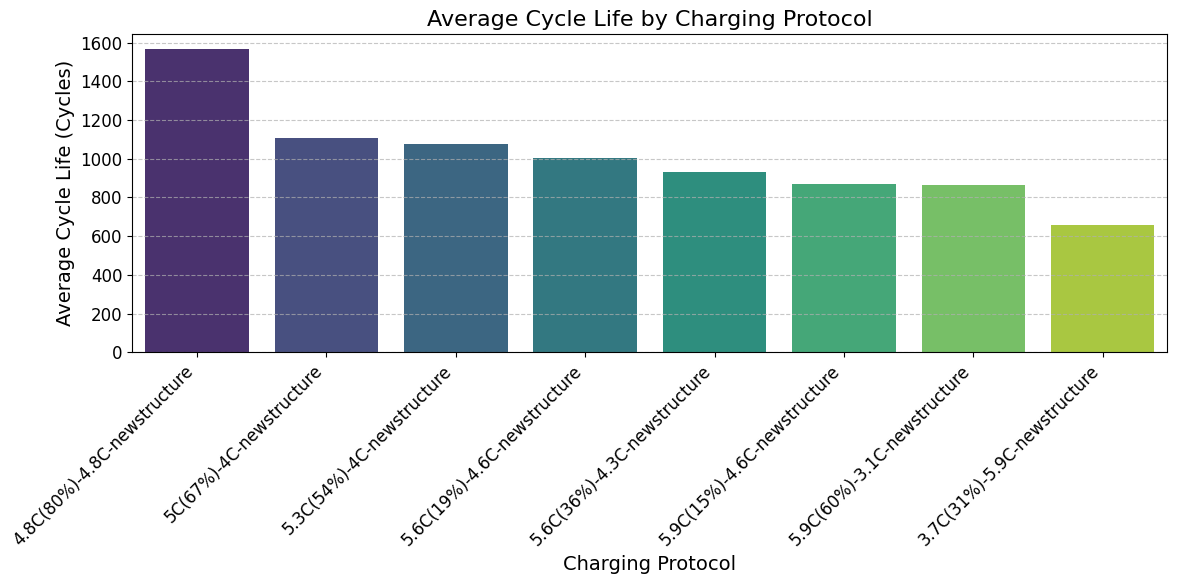


📌 [충전 프로토콜별 평균 수명 수치]
policy_readable
4.8C(80%)-4.8C-newstructure    1564.166667
5C(67%)-4C-newstructure        1105.714286
5.3C(54%)-4C-newstructure      1074.375000
5.6C(19%)-4.6C-newstructure    1001.375000
5.6C(36%)-4.3C-newstructure     930.875000
5.9C(15%)-4.6C-newstructure     867.000000
5.9C(60%)-3.1C-newstructure     866.500000
3.7C(31%)-5.9C-newstructure     660.000000
Name: cycle_life, dtype: float64


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_list = []

for i, cell in enumerate(batch):
    # A. 수명 데이터 (Target)
    cl = cell['cycle_life']
    cycle_life = float(np.atleast_1d(cl)[0])
    
    # B. 충전 프로토콜 (텍스트)
    policy = cell['policy_readable']
    if isinstance(policy, (list, np.ndarray)):
        policy = str(policy[0])
    else:
        policy = str(policy)
        
    # 리스트에 담기
    data_list.append({
        'cell_id': f'Cell_{i+1}',
        'policy_readable': policy,
        'cycle_life': cycle_life
    })

# DataFrame 생성
df = pd.DataFrame(data_list)
display(df.head())

# ==========================================
# 충전 프로토콜별 평균 수명 시각화
# ==========================================
# 같은 프로토콜(policy_readable)끼리 묶어서 수명(cycle_life)의 평균을 내고, 긴 순서대로 정렬합니다.
policy_mean = df.groupby('policy_readable')['cycle_life'].mean().sort_values(ascending=False)

# 막대그래프(Bar plot) 그리기
plt.figure(figsize=(12, 6))
sns.barplot(x=policy_mean.index, y=policy_mean.values, palette='viridis')

plt.title('Average Cycle Life by Charging Protocol', fontsize=16)
plt.xlabel('Charging Protocol', fontsize=14)
plt.ylabel('Average Cycle Life (Cycles)', fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# 실제 계산된 평균 수명 수치로도 확인하기
print("\n📌 [충전 프로토콜별 평균 수명 수치]")
print(policy_mean)

### (Q2) 사이클 별 Qd 추이 시각화

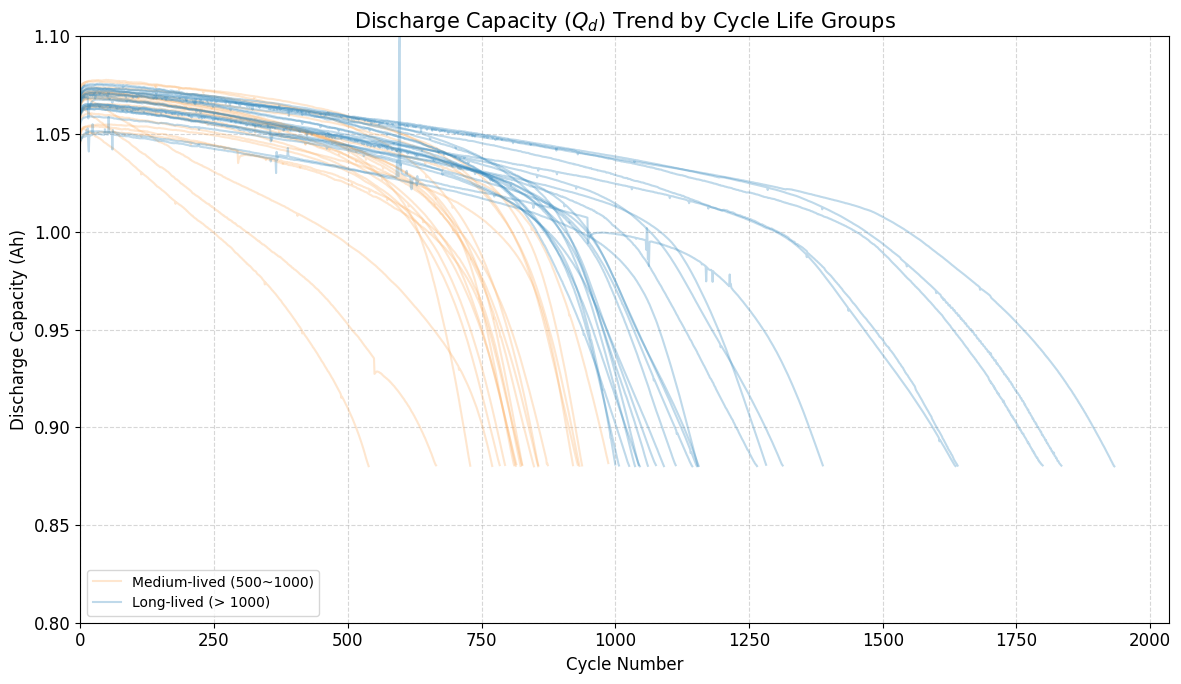

📌 그룹별 배터리 개수 확인
- Short-lived  : 0개
- Medium-lived : 21개
- Long-lived   : 23개


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 수명 구간별 그룹화 (Short, Medium, Long)
# 인덱스를 맞춰주기 위해 df의 수명 정보를 기준으로 각 셀을 분류합니다.
short_life_indices = df[df['cycle_life'] <= 500].index
medium_life_indices = df[(df['cycle_life'] > 500) & (df['cycle_life'] <= 1000)].index
long_life_indices = df[df['cycle_life'] > 1000].index

# 2. 시각화 설정
plt.figure(figsize=(12, 7))

def plot_qd_trend(indices, label, color):
    first_flag = True
    for idx in indices:
        cell = batch[idx]
        # summary에서 방전 용량(Qd) 데이터 추출 및 차원 정리
        qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
        qd_flat = np.array(qd).flatten()
        
        cycles = np.arange(len(qd_flat))
        
        # 각 그룹별로 첫 번째 선에만 범례(Label) 표시
        current_label = label if first_flag else None
        plt.plot(cycles, qd_flat, color=color, alpha=0.3, label=current_label)
        first_flag = False

# 3. 각 구간별 데이터 플로팅
plot_qd_trend(short_life_indices, 'Short-lived (<= 500)', '#d7191c')   # 빨간색계열
plot_qd_trend(medium_life_indices, 'Medium-lived (500~1000)', '#fdae61') # 주황색계열
plot_qd_trend(long_life_indices, 'Long-lived (> 1000)', '#2b83ba')     # 파란색계열

# 4. 그래프 디테일 설정
plt.title('Discharge Capacity ($Q_d$) Trend by Cycle Life Groups', fontsize=15)
plt.xlabel('Cycle Number', fontsize=12)
plt.ylabel('Discharge Capacity (Ah)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# 그래프 범위 설정 (수명이 긴 배터리 기준으로 X축 최댓값 설정)
max_cycle = df['cycle_life'].max()
plt.xlim(0, max_cycle + 100)
plt.ylim(0.8, 1.1) # 일반적인 LFP 배터리 용량 범위에 맞춰 조정

plt.tight_layout()
plt.show()

# 5. 각 그룹별 샘플 수 확인
print(f"📌 그룹별 배터리 개수 확인")
print(f"- Short-lived  : {len(short_life_indices)}개")
print(f"- Medium-lived : {len(medium_life_indices)}개")
print(f"- Long-lived   : {len(long_life_indices)}개")

### 고속 충전 셀이 정말 수명이 짧은가? (Batch 3)

데이터 확인:


,policy_readable,first_c_rate,soc_percent,second_c_rate,cycle_life
0,5C(67%)-4C-newstructure,5.0,67.0,4.0,1009.0
1,5.3C(54%)-4C-newstructure,5.3,54.0,4.0,1063.0
2,5.6C(19%)-4.6C-newstructure,5.6,19.0,4.6,1267.0
3,5.6C(36%)-4.3C-newstructure,5.6,36.0,4.3,1115.0
4,5.6C(19%)-4.6C-newstructure,5.6,19.0,4.6,1048.0


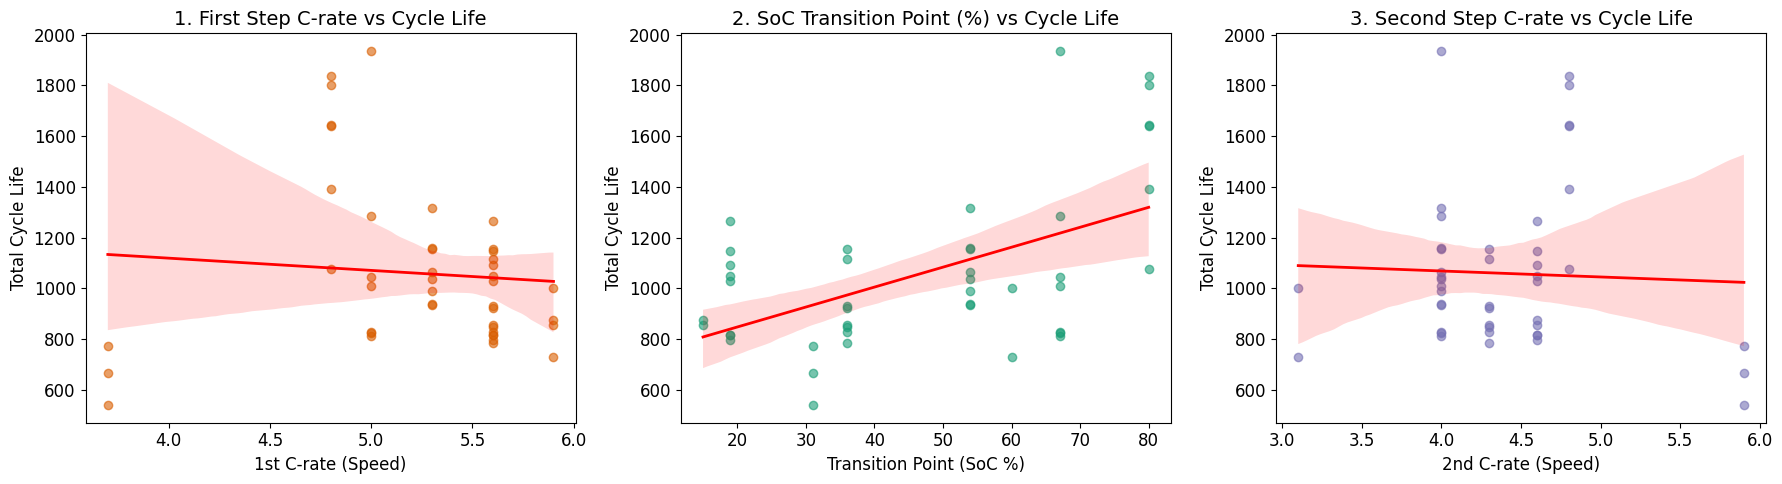


📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]
- 1차 충전 속도의 영향력 : -0.083 (가장 강력한 음의 상관관계)
- 전환 구간(%)의 영향력   : 0.541
- 2차 충전 속도의 영향력 : -0.043


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# policy_readable에서 3가지 변수 분리
# ==========================================
# policy_readable 문자열 (예: '5.4C(40%)-3.0C')에서 각각의 숫자 추출
# 1) 1차 충전 속도
df['first_c_rate'] = (df['policy_readable']
                      .str.extract(r'^(\d+(?:[._]\d+)?)C', expand=False)
                      .str.replace('_', '.')
                      .astype(float))

# 2) 전환 구간(%)
df['soc_percent'] = (df['policy_readable']
                     .str.extract(r'(\d+)(?:PER|%)', expand=False)
                     .astype(float))

# 3) 2차 충전 속도
df['second_c_rate'] = (df['policy_readable']
                       .str.extract(r'(?:PER_|-)(\d+(?:[._]\d+)?)C', expand=False)
                       .str.replace('_', '.')
                       .astype(float))

print("데이터 확인:")
display(df[['policy_readable', 'first_c_rate', 'soc_percent', 'second_c_rate', 'cycle_life']].head())

# ==========================================
# 3가지 변수와 최종 수명(Target)의 관계 시각화
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# [그래프 1] 1차 충전 속도 vs 수명
sns.regplot(x='first_c_rate', y='cycle_life', data=df, ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'#d95f02'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First Step C-rate vs Cycle Life', fontsize=14)
axes[0].set_xlabel('1st C-rate (Speed)', fontsize=12)
axes[0].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 2] 1차 충전 유지 구간(%) vs 수명
sns.regplot(x='soc_percent', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.6, 'color':'#1b9e77'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. SoC Transition Point (%) vs Cycle Life', fontsize=14)
axes[1].set_xlabel('Transition Point (SoC %)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

# [그래프 3] 2차 충전 속도 vs 수명
sns.regplot(x='second_c_rate', y='cycle_life', data=df, ax=axes[2],
            scatter_kws={'alpha':0.6, 'color':'#7570b3'}, line_kws={'color':'red', 'lw':2})
axes[2].set_title('3. Second Step C-rate vs Cycle Life', fontsize=14)
axes[2].set_xlabel('2nd C-rate (Speed)', fontsize=12)
axes[2].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 피어슨 상관계수로 확인
# ==========================================
print("\n📌 [각 충전 변수와 수명(Cycle Life)의 상관계수]")
corr_1st = df['first_c_rate'].corr(df['cycle_life'])
corr_soc = df['soc_percent'].corr(df['cycle_life'])
corr_2nd = df['second_c_rate'].corr(df['cycle_life'])

print(f"- 1차 충전 속도의 영향력 : {corr_1st:.3f} (가장 강력한 음의 상관관계)")
print(f"- 전환 구간(%)의 영향력   : {corr_soc:.3f}")
print(f"- 2차 충전 속도의 영향력 : {corr_2nd:.3f}")

### 충전 전류 패턴과 열화 속도 상관 분석 (Batch 3)

열화 속도(early_degradation_100) 컬럼 추가 완료


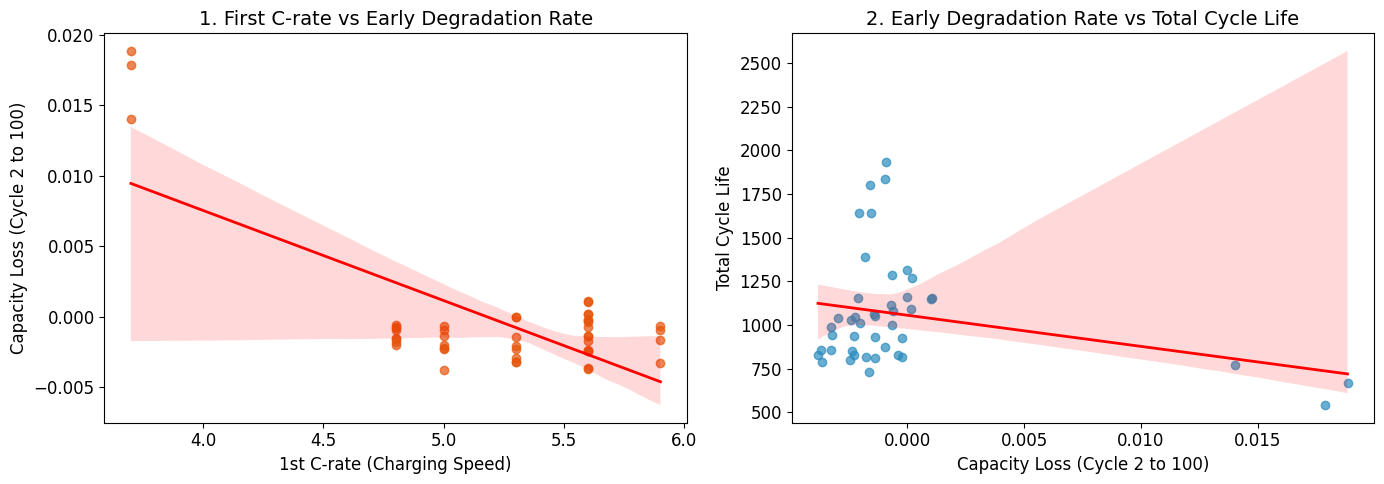


📌 [상관 분석 결과]
- 충전 속도와 초기 열화 속도의 상관계수 : -0.718
- 초기 열화 속도와 최종 수명의 상관계수   : -0.277


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 원본 batch에서 '초기 열화 속도' 계산
# ==========================================
degradation_list = []
for cell in batch:
    # summary에서 방전 용량(Qd) 배열 가져오기
    summary_qd = cell['summary'].get('QDischarge', cell['summary'].get('Qd', []))
    
    # 2번째 사이클(인덱스 1)과 100번째 사이클(인덱스 99)의 용량 차이(감소량) 계산
    if len(summary_qd) >= 100:
        early_deg = float(summary_qd[1]) - float(summary_qd[99])
    else:
        early_deg = np.nan
        
    degradation_list.append(early_deg)

# df에 '초기 100사이클 열화량' 컬럼 추가
df['early_degradation_100'] = degradation_list

print("열화 속도(early_degradation_100) 컬럼 추가 완료")

# ==========================================
# 충전 속도 vs 열화 속도 vs 최종 수명 시각화
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] 1차 충전 속도 vs 초기 열화 속도
sns.regplot(x='first_c_rate', y='early_degradation_100', data=df, ax=axes[0],
            scatter_kws={'alpha':0.7, 'color':'#e6550d'}, line_kws={'color':'red', 'lw':2})
axes[0].set_title('1. First C-rate vs Early Degradation Rate', fontsize=14)
axes[0].set_xlabel('1st C-rate (Charging Speed)', fontsize=12)
axes[0].set_ylabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)

# [그래프 2] 초기 열화 속도 vs 최종 수명
sns.regplot(x='early_degradation_100', y='cycle_life', data=df, ax=axes[1],
            scatter_kws={'alpha':0.7, 'color':'#2b8cbe'}, line_kws={'color':'red', 'lw':2})
axes[1].set_title('2. Early Degradation Rate vs Total Cycle Life', fontsize=14)
axes[1].set_xlabel('Capacity Loss (Cycle 2 to 100)', fontsize=12)
axes[1].set_ylabel('Total Cycle Life', fontsize=12)

plt.tight_layout()
plt.show()

# ==========================================
# 상관계수 확인
# ==========================================
print("\n📌 [상관 분석 결과]")
corr_c_deg = df['first_c_rate'].corr(df['early_degradation_100'])
corr_deg_life = df['early_degradation_100'].corr(df['cycle_life'])

print(f"- 충전 속도와 초기 열화 속도의 상관계수 : {corr_c_deg:.3f}")
print(f"- 초기 열화 속도와 최종 수명의 상관계수   : {corr_deg_life:.3f}")

### Correlation Matrix

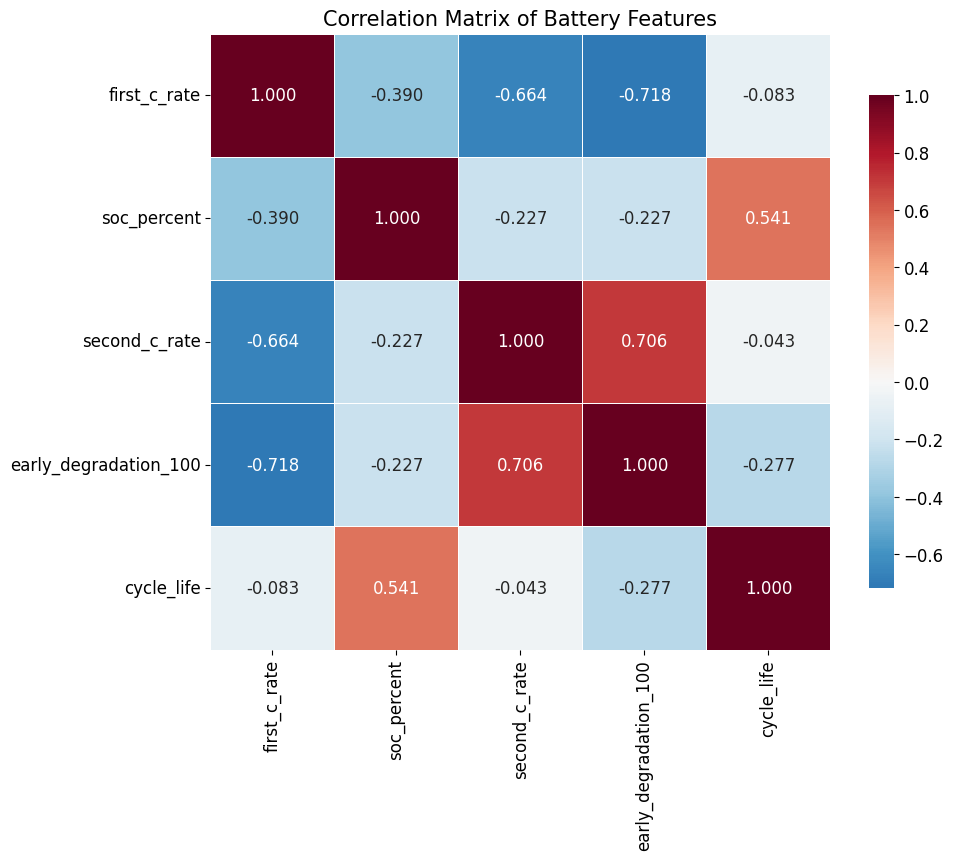


📌 [수명(cycle_life)과의 상관계수 순위]
cycle_life               1.000000
soc_percent              0.541360
second_c_rate           -0.042746
first_c_rate            -0.082899
early_degradation_100   -0.277331
Name: cycle_life, dtype: float64


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관분석에 사용할 핵심 변수들만 선택
# (기존에 정규표현식으로 추출한 변수들이 df에 포함되어 있어야 합니다)
features = ['first_c_rate', 'soc_percent', 'second_c_rate', 'early_degradation_100', 'cycle_life']

# 2. 상관계수 계산 (데이터프레임 내 변수 간의 피어슨 상관계수)
corr = df[features].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr, 
            annot=True,           # 숫자 표시
            fmt=".3f",            # 소수점 셋째자리까지
            cmap='RdBu_r',        # 빨간색(양의 상관), 파란색(음의 상관)
            center=0,             # 0을 기준으로 색상 분리
            linewidths=0.5,       # 칸 사이 구분선
            cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Battery Features', fontsize=15)
plt.show()

# 4. 수명(cycle_life)과의 상관계수만 따로 내림차순 정렬해서 보기
print(f"\n📌 [수명(cycle_life)과의 상관계수 순위]")
print(corr['cycle_life'].sort_values(ascending=False))